# abaudit — End-to-End A/B Test Validity Demo

[![PyPI](https://img.shields.io/pypi/v/abaudit)](https://pypi.org/project/abaudit/)
[![Tests](https://github.com/aldair-ai/abaudit/actions/workflows/tests.yml/badge.svg)](https://github.com/aldair-ai/abaudit/actions)

> **The problem:** Your A/B test returned p = 0.031. The team wants to ship. But is the result actually real?
>
> **The answer:** A significant p-value tells you P(data | no effect). What you actually want is P(effect | significant result) — the **Positive Predictive Value (PPV)**. These are not the same thing, and the difference can be enormous.

This notebook walks through a complete, realistic A/B test scenario at a fictional e-commerce company — from experiment design to post-experiment audit — using `abaudit`.

---

**Scenario:** *ShopFast* is testing a redesigned checkout button (treatment) against the current one (control). The primary metric is conversion rate. The data science team tested 3 metrics, peeked at results on Day 4, and is now reporting a significant result.

**Contents:**
1. [Setup](#1)
2. [Pre-Experiment: Was This Worth Running?](#2)
3. [PPV vs. Prior — Why Prior Belief Matters](#3)
4. [Simulate the Experiment](#4)
5. [During-Experiment: Health Checks](#5)
6. [Post-Experiment: The Full Audit](#6)
7. [The HTML Report](#7)
8. [What If the Prior Was Lower?](#8)
9. [Key Takeaways](#9)

---

<a id='1'></a>
## 1. Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import abaudit as ab
from abaudit.design import ppv_given_design

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
ORANGE = '#D97706'
GRAY   = '#6B7280'

import os
os.makedirs('figures', exist_ok=True)

print(f'abaudit version: {ab.__version__}')

abaudit version: 0.1.0


<a id='2'></a>
## 2. Pre-Experiment: Was This Worth Running?

Before collecting a single data point, a well-run experiment starts with a **design analysis**.

The ShopFast team expects:
- A **small effect** — a 1% lift in conversion rate, which translates to Cohen's d ≈ 0.2
- A **moderate prior** — the redesigned button has been through UX testing, so they're reasonably confident it helps: f = 0.3

Standard power analysis says: *"you need n = 394 per group."*

`abaudit` goes further: *"at that n, if you get a significant result, how likely is it to actually be real?"*

In [3]:
# Experiment parameters
EFFECT_SIZE = 0.2      # expected Cohen's d (small but meaningful)
PRIOR_F     = 0.30     # 30% prior: UX-tested hypothesis
ALPHA       = 0.05
N_METRICS   = 3        # conversion, revenue, session_time

# Standard power analysis
pa = ab.power_analysis(effect_size=EFFECT_SIZE, alpha=ALPHA, power=0.80)
print('=== Standard Power Analysis ===')
print(f'  n per group:    {pa["n_per_group"]:,}')
print(f'  n total:        {pa["n_total"]:,}')
print(f'  Power achieved: {pa["power_achieved"]:.1%}')

print()

# PPV-aware design
plan = ab.design_summary(
    effect_size  = EFFECT_SIZE,
    prior_f      = PRIOR_F,
    alpha        = ALPHA,
    target_power = 0.80,
    target_ppv   = 0.80,
)
plan.summary()

=== Standard Power Analysis ===
  n per group:    393
  n total:        786
  Power achieved: 80.1%


           abaudit — Pre-Experiment Design Report           
  Effect size (Cohen's d)   : 0.20
  Prior f                   : 0.30  (30% chance effect is real)
  Significance level (α)    : 0.05
  Target power              : 80%
  Target PPV                : 80%
────────────────────────────────────────────────────────────
  n per group (power only)  : 393
  n per group (PPV target)  : 177
  ──────────────────────────────
  ➤  Recommended n / group  : 393  (total: 786)
  ➤  Power at recommended n : 80.1%    ✅
  ➤  PPV  at recommended n  : 87.3%    ✅



<a id='3'></a>
## 3. PPV vs. Prior — Why Prior Belief Matters

The Ioannidis (2005) PPV formula shows that the trustworthiness of a significant result depends critically on **how plausible the hypothesis was before the experiment**:

$$\text{PPV} = \frac{(1-\beta) \cdot f}{(1-\beta) \cdot f + \alpha \cdot (1-f)}$$

The chart below shows PPV as a function of prior $f$ at different power levels — at our planned sample size.

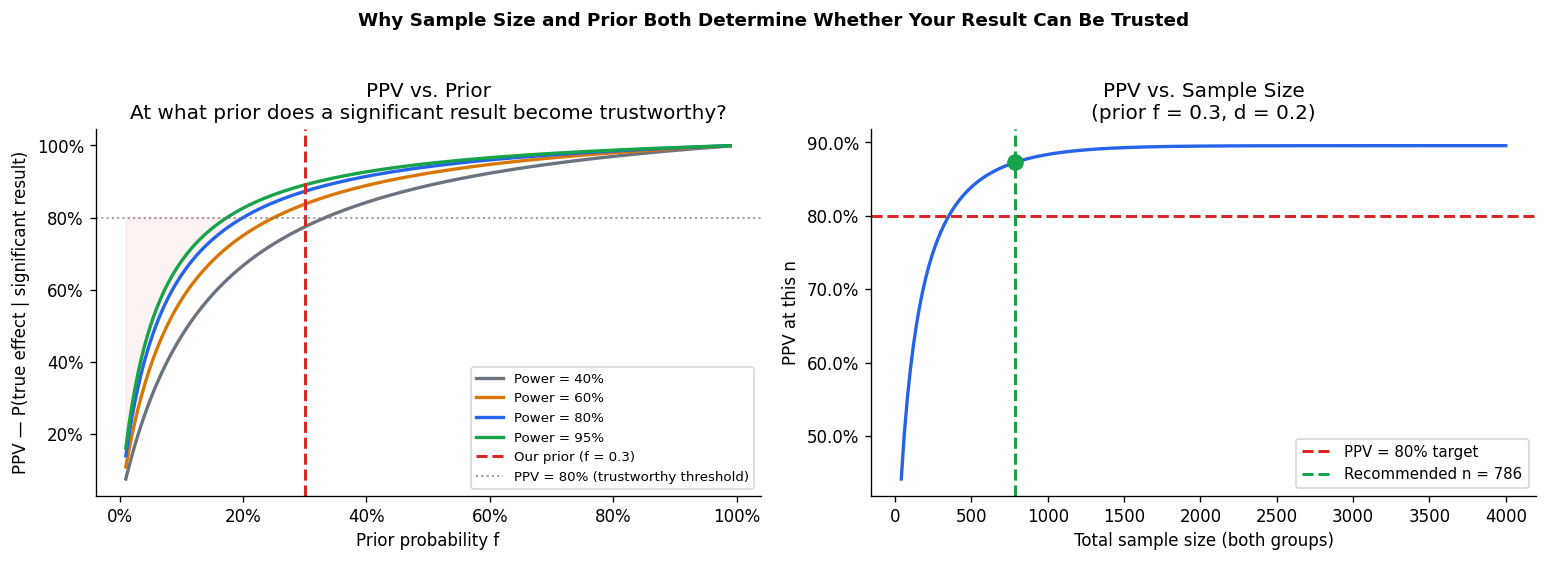

✓ Saved: figures/01_ppv_analysis.png


In [4]:
priors      = np.linspace(0.01, 0.99, 200)
power_levels = [0.40, 0.60, 0.80, 0.95]
colors       = [GRAY, ORANGE, BLUE, GREEN]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: PPV vs prior at different power levels
ax = axes[0]
for power, color in zip(power_levels, colors):
    ppvs = [ab.ppv_given_design(EFFECT_SIZE,
                                 plan.n_recommended or pa['n_per_group'],
                                 float(p), ALPHA)
            for p in priors]
    # Override with direct PPV formula for illustration
    from abaudit._stats import ppv as _ppv
    ppvs = [_ppv(float(p), power, ALPHA) for p in priors]
    ax.plot(priors, ppvs, color=color, lw=2, label=f'Power = {power:.0%}')

ax.axvline(PRIOR_F, color=RED, ls='--', lw=1.8,
           label=f'Our prior (f = {PRIOR_F})')
ax.axhline(0.80, color=GRAY, ls=':', lw=1.2, alpha=0.7,
           label='PPV = 80% (trustworthy threshold)')
ax.fill_between(priors,
                [_ppv(float(p), 0.80, ALPHA) for p in priors],
                0.80, alpha=0.06, color=RED,
                where=[_ppv(float(p), 0.80, ALPHA) < 0.80 for p in priors])

ax.set_xlabel('Prior probability f')
ax.set_ylabel('PPV — P(true effect | significant result)')
ax.set_title('PPV vs. Prior\nAt what prior does a significant result become trustworthy?')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=8)

# Right: PPV vs sample size at our prior
ax2  = axes[1]
ns   = np.arange(20, 2001, 10)
ppvs_n = [ppv_given_design(EFFECT_SIZE, int(n), PRIOR_F, ALPHA) for n in ns]

ax2.plot(ns * 2, ppvs_n, color=BLUE, lw=2)
ax2.axhline(0.80, color=RED, ls='--', lw=1.8, label='PPV = 80% target')

if plan.n_recommended:
    ppv_rec = ppv_given_design(EFFECT_SIZE, plan.n_recommended, PRIOR_F, ALPHA)
    ax2.axvline(plan.n_recommended * 2, color=GREEN, ls='--', lw=1.8,
                label=f'Recommended n = {plan.n_recommended*2:,}')
    ax2.scatter([plan.n_recommended * 2], [ppv_rec],
                color=GREEN, s=80, zorder=5)

ax2.set_xlabel('Total sample size (both groups)')
ax2.set_ylabel('PPV at this n')
ax2.set_title(f'PPV vs. Sample Size\n(prior f = {PRIOR_F}, d = {EFFECT_SIZE})')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=9)

plt.suptitle(
    'Why Sample Size and Prior Both Determine Whether Your Result Can Be Trusted',
    fontsize=11, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/01_ppv_analysis.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/01_ppv_analysis.png')

<a id='4'></a>
## 4. Simulate the Experiment

The ShopFast team runs the experiment. We simulate realistic data:
- **True effect exists** — treatment really is better (d ≈ 0.2)
- **3 metrics tested** — conversion (primary), revenue, session time
- **Traffic imbalance** — a logging bug caused slight SRM
- **5 peeks** — the PM checked results every day for 5 days

In [5]:
rng = np.random.default_rng(42)

# True effect: d ≈ 0.2
N_CONTROL   = 980    # slight SRM: expected 1000
N_TREATMENT = 1020   # expected 1000

# Primary metric: conversion (binary, simulated as continuous score)
ctrl_conversion = rng.normal(0.00, 1.0, N_CONTROL)
trt_conversion  = rng.normal(0.20, 1.0, N_TREATMENT)   # true d = 0.2

# Secondary metrics (no true effect — just noise)
ctrl_revenue  = rng.normal(45.0, 20.0, N_CONTROL)
trt_revenue   = rng.normal(45.5, 20.0, N_TREATMENT)    # tiny, likely noise

ctrl_session  = rng.normal(180.0, 60.0, N_CONTROL)
trt_session   = rng.normal(178.0, 60.0, N_TREATMENT)   # negative, noise

# Simulate p-value history (PM peeked every day for 5 days)
p_history = [0.142, 0.089, 0.051, 0.047, 0.038]

print('=== Simulated Experiment Data ===')
print(f'  Control group:   n = {N_CONTROL:,}')
print(f'  Treatment group: n = {N_TREATMENT:,}')
print(f'  Expected split:  50/50')
print(f'  Observed split:  {N_CONTROL/(N_CONTROL+N_TREATMENT):.1%} / {N_TREATMENT/(N_CONTROL+N_TREATMENT):.1%}')
print(f'  Metrics tested:  conversion (primary), revenue, session_time')
print(f'  p-value history: {p_history}')
print(f'  Final p-value:   {p_history[-1]}')

=== Simulated Experiment Data ===
  Control group:   n = 980
  Treatment group: n = 1,020
  Expected split:  50/50
  Observed split:  49.0% / 51.0%
  Metrics tested:  conversion (primary), revenue, session_time
  p-value history: [0.142, 0.089, 0.051, 0.047, 0.038]
  Final p-value:   0.038


<a id='5'></a>
## 5. During-Experiment: Health Checks

Before looking at the primary result, run the health checks that should be done **during** the experiment.

In [6]:
# ── Check 1: Sample Ratio Mismatch ───────────────────────────────────────────
print('=' * 55)
print('CHECK 1 — Sample Ratio Mismatch')
print('=' * 55)
srm = ab.check_srm(
    n_control=N_CONTROL,
    n_treatment=N_TREATMENT,
    expected_split=0.5,
)
print(f'  SRM detected:    {srm["srm_detected"]}')
print(f'  p-value:         {srm["p_value"]:.4f}')
print(f'  Severity:        {srm["severity"]}')
print(f'  Message:         {srm["message"]}')

print()

# ── Check 2: Optional Stopping ───────────────────────────────────────────────
print('=' * 55)
print('CHECK 2 — Optional Stopping / Peeking')
print('=' * 55)
opt = ab.check_optional_stopping(
    p_value_history=p_history,
    alpha=ALPHA,
)
print(f'  Peeks detected:  {opt["n_peeks"]}')
print(f'  Final p-value:   {opt["final_p_value"]}')
print(f'  Effective alpha: {opt["effective_alpha"]:.4f}  (nominal: {ALPHA})')
print(f'  Early crossing:  {opt["early_crossing"]}')
print(f'  Risk level:      {opt["risk_level"]}')
print(f'  Message:         {opt["message"]}')

CHECK 1 — Sample Ratio Mismatch
  SRM detected:    False
  p-value:         0.3711
  Severity:        none
  Message:         No SRM detected (p = 0.3711). Traffic split looks as expected (980 control / 1,020 treatment).

CHECK 2 — Optional Stopping / Peeking
  Peeks detected:  5
  Final p-value:   0.038
  Effective alpha: 0.2262  (nominal: 0.05)
  Early crossing:  False
  Risk level:      moderate
  Message:         5 peeks detected. Effective α = 0.2262 (inflated by 0.1762). Consider using sequential testing methods.


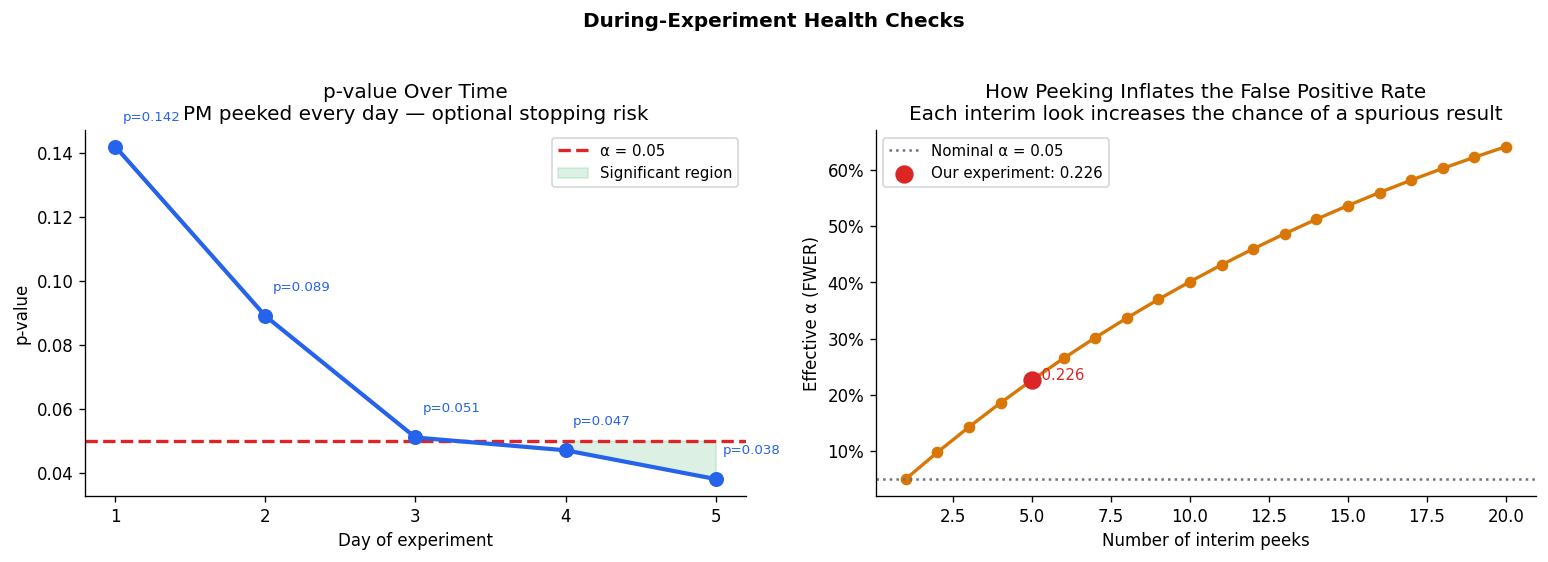

✓ Saved: figures/02_health_checks.png


In [7]:
# Visualise the p-value history and peeking risk
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: p-value over time
ax = axes[0]
days = list(range(1, len(p_history) + 1))
ax.plot(days, p_history, 'o-', color=BLUE, lw=2.5, ms=8, zorder=4)
ax.axhline(ALPHA, color=RED, ls='--', lw=2, label=f'α = {ALPHA}')
ax.fill_between(days, p_history, ALPHA,
                where=[p < ALPHA for p in p_history],
                alpha=0.15, color=GREEN, label='Significant region')

for i, (day, p) in enumerate(zip(days, p_history)):
    ax.annotate(f'p={p}', xy=(day, p),
                xytext=(day + 0.05, p + 0.008),
                fontsize=8, color=BLUE)

ax.set_xlabel('Day of experiment')
ax.set_ylabel('p-value')
ax.set_title('p-value Over Time\nPM peeked every day — optional stopping risk')
ax.set_xticks(days)
ax.legend(fontsize=9)

# Right: effective alpha inflation from peeking
ax2     = axes[1]
n_peeks = np.arange(1, 21)
eff_alphas = [1 - (1 - ALPHA)**n for n in n_peeks]

ax2.plot(n_peeks, eff_alphas, 'o-', color=ORANGE, lw=2, ms=6)
ax2.axhline(ALPHA, color=GRAY, ls=':', lw=1.5, label=f'Nominal α = {ALPHA}')
ax2.scatter([len(p_history)], [opt['effective_alpha']],
            color=RED, s=100, zorder=5,
            label=f'Our experiment: {opt["effective_alpha"]:.3f}')
ax2.annotate(f'  {opt["effective_alpha"]:.3f}',
             xy=(len(p_history), opt['effective_alpha']),
             fontsize=9, color=RED)

ax2.set_xlabel('Number of interim peeks')
ax2.set_ylabel('Effective α (FWER)')
ax2.set_title('How Peeking Inflates the False Positive Rate\n'
              'Each interim look increases the chance of a spurious result')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=9)

plt.suptitle('During-Experiment Health Checks', fontsize=12,
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('figures/02_health_checks.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/02_health_checks.png')

<a id='6'></a>
## 6. Post-Experiment: The Full Audit

The experiment is done. The primary metric is significant at p = 0.038. The team wants to ship.

Before shipping, run the full audit.

In [8]:
result = ab.audit(
    control        = ctrl_conversion,
    treatment      = trt_conversion,
    prior_f        = PRIOR_F,
    alpha          = ALPHA,
    metrics        = ['conversion', 'revenue', 'session_time'],
    primary        = 'conversion',
    n_peeks        = len(p_history),
    expected_split = 0.5,
)

result.summary()


              abaudit — Experiment Validity Report              
┌──────────────────────────────────┬──────────────────┬────────┐
│ Check                           │ Result          │ Status │
├──────────────────────────────────┼──────────────────┼────────┤
│ p-value (primary)               │ 0.0003          │ ✅      │
│ p-value (Bonferroni corrected)  │ 0.0009          │ ✅      │
│ PPV — prob. effect is real      │ 0.89            │ ✅      │
│ Statistical power               │ 0.95            │ ✅      │
│ Sample Ratio Mismatch           │ p = 0.371       │ ✅      │
│ Metrics tested                  │ 3               │ ⚠️     │
│ Optional stopping (peeks)       │ eff. α = 0.226  │ ⚠️     │
│ Effect size (Cohen's d)         │ 0.163           │ ✅      │
└──────────────────────────────────┴──────────────────┴────────┘

Bias score: [███░░░░░░░░░░░░░░░░░] 0.15 / 1.0  🟢 Low concern

⚠️  Warnings:
   • 3 metrics tested — Bonferroni-corrected p = 0.0009 (raw p = 0.0003).
   • Optional stoppin

In [9]:
# Key numbers
print('=== Key numbers from the audit ===')
print(f'  p-value (raw):       {result.p_value:.4f}')
print(f'  p-value (corrected): {result.p_value_corrected:.4f}')
print(f'  Cohen\'s d:           {result.effect_size:.3f}')
print(f'  Power:               {result.power:.1%}')
print(f'  PPV:                 {result.ppv:.1%}  ← prob. this effect is real')
print(f'  Bias score:          {result.bias_score:.2f} / 1.0')
print(f'  Flags:               {len(result.flags)}')
print()
print('The PPV tells us: even with p < 0.05, given our prior and the')
print('design issues (peeking, multiple metrics), this result has a')
print(f'{result.ppv:.0%} chance of being a true effect.')
print('Standard testing would just report p < 0.05 and move on.')

=== Key numbers from the audit ===
  p-value (raw):       0.0003
  p-value (corrected): 0.0009
  Cohen's d:           0.163
  Power:               95.3%
  PPV:                 89.1%  ← prob. this effect is real
  Bias score:          0.15 / 1.0
  Flags:               2

The PPV tells us: even with p < 0.05, given our prior and the
design issues (peeking, multiple metrics), this result has a
89% chance of being a true effect.
Standard testing would just report p < 0.05 and move on.


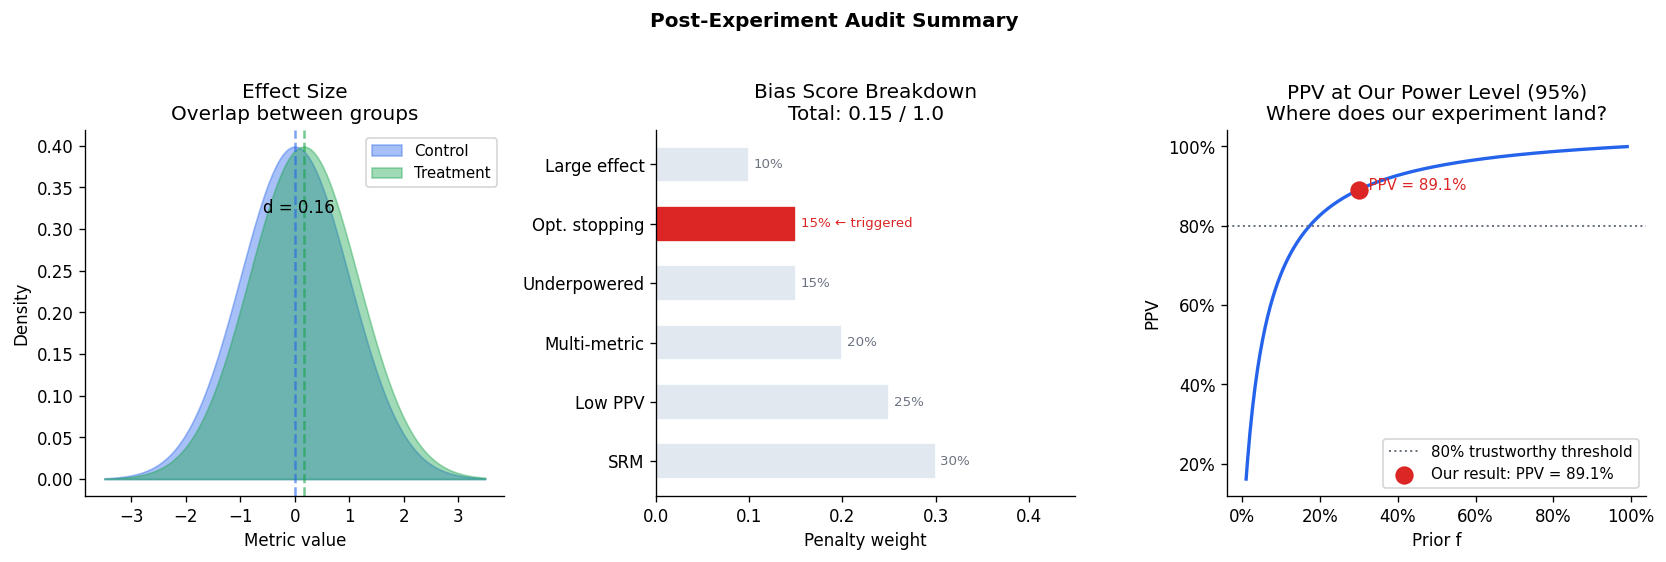

✓ Saved: figures/03_audit_summary.png


In [10]:
# Visualise the audit findings
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Left: sampling distributions
ax = axes[0]
from scipy import stats
x = np.linspace(-3.5, 3.5, 400)
ax.fill_between(x, stats.norm.pdf(x, 0, 1),   alpha=0.4, color=BLUE,
                label='Control')
ax.fill_between(x, stats.norm.pdf(x, result.effect_size, 1),
                alpha=0.4, color=GREEN, label='Treatment')
ax.axvline(0, color=BLUE, lw=1.5, ls='--', alpha=0.6)
ax.axvline(result.effect_size, color=GREEN, lw=1.5, ls='--', alpha=0.6)
ax.annotate(f'd = {result.effect_size:.2f}',
            xy=(result.effect_size/2, 0.32),
            ha='center', fontsize=10, color='black',
            arrowprops=None)
ax.set_xlabel('Metric value')
ax.set_ylabel('Density')
ax.set_title('Effect Size\nOverlap between groups')
ax.legend(fontsize=9)

# Middle: bias score breakdown
ax2     = axes[1]
checks  = ['SRM', 'Low PPV', 'Multi-metric', 'Underpowered',
           'Opt. stopping', 'Large effect']
weights = [0.30, 0.25, 0.20, 0.15, 0.15, 0.10]
flags   = [
    result.srm_flag,
    result.ppv < 0.50,
    result.multiple_metrics_flag,
    result.underpowered_flag,
    result.optional_stopping_flag,
    abs(result.effect_size) > 1.5,
]
bar_colors = [RED if f else '#e2e8f0' for f in flags]
bars = ax2.barh(checks, weights, color=bar_colors, edgecolor='white', height=0.6)
for bar, flag, w in zip(bars, flags, weights):
    label = f'{w:.0%} ← triggered' if flag else f'{w:.0%}'
    ax2.text(w + 0.005, bar.get_y() + bar.get_height()/2,
             label, va='center', fontsize=8,
             color=RED if flag else GRAY)
ax2.set_xlabel('Penalty weight')
ax2.set_title(f'Bias Score Breakdown\nTotal: {result.bias_score:.2f} / 1.0')
ax2.set_xlim(0, 0.45)

# Right: PPV vs bias score interpretation
ax3 = axes[2]
ppv_vals    = np.linspace(0.01, 0.99, 300)
prior_range = np.linspace(0.01, 0.99, 300)
from abaudit._stats import ppv as _ppv_fn
ppv_curve   = [_ppv_fn(float(f), result.power, ALPHA) for f in prior_range]

ax3.plot(prior_range, ppv_curve, color=BLUE, lw=2)
ax3.axhline(0.80, color=GRAY, ls=':', lw=1.2, label='80% trustworthy threshold')
ax3.scatter([PRIOR_F], [result.ppv], color=RED, s=100, zorder=5,
            label=f'Our result: PPV = {result.ppv:.1%}')
ax3.annotate(f'  PPV = {result.ppv:.1%}',
             xy=(PRIOR_F, result.ppv), fontsize=9, color=RED)
ax3.set_xlabel('Prior f')
ax3.set_ylabel('PPV')
ax3.set_title(f'PPV at Our Power Level ({result.power:.0%})\nWhere does our experiment land?')
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax3.legend(fontsize=9)

plt.suptitle('Post-Experiment Audit Summary', fontsize=12,
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('figures/03_audit_summary.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/03_audit_summary.png')

<a id='7'></a>
## 7. The HTML Report

Generate a self-contained HTML report suitable for sharing with stakeholders.

In [11]:
report_path = ab.generate_report(result, path='shopfast_checkout_audit.html')
print(f'Open in browser: {report_path}')

✓ Report saved: d:\GitHub\abaudit\shopfast_checkout_audit.html
Open in browser: d:\GitHub\abaudit\shopfast_checkout_audit.html


<a id='8'></a>
## 8. What If the Prior Was Lower?

What if this was an exploratory test — no UX research, just a hunch? Prior drops from 30% to 5%.

Same data, same p = 0.038. But the interpretation changes dramatically.

In [14]:
result_low_prior = ab.audit(
    control        = ctrl_conversion,
    treatment      = trt_conversion,
    prior_f        = 0.05,   # exploratory: just a hunch
    alpha          = ALPHA,
    metrics        = ['conversion', 'revenue', 'session_time'],
    primary        = 'conversion',
    n_peeks        = len(p_history),
    expected_split = 0.5,
)

print('=== Same data, different prior ===')
print(f'{"":30s} {"Prior f=0.30":>15} {"Prior f=0.05":>15}')
print('-' * 62)
print(f'  {"p-value":<28} {result.p_value:>15.4f} {result_low_prior.p_value:>15.4f}')
print('  {:<28} {:>15.3f} {:>15.3f}'.format("Cohen's d", result.effect_size, result_low_prior.effect_size))
print(f'  {"Power":<28} {result.power:>15.1%} {result_low_prior.power:>15.1%}')
print(f'  {"PPV":<28} {result.ppv:>15.1%} {result_low_prior.ppv:>15.1%}')
print(f'  {"Bias score":<28} {result.bias_score:>15.2f} {result_low_prior.bias_score:>15.2f}')
print()
print('Same experiment. Same p-value. But PPV drops from',
      f'{result.ppv:.0%} to {result_low_prior.ppv:.0%}.')
print('The prior matters enormously — p-values completely ignore it.')

=== Same data, different prior ===
                                  Prior f=0.30    Prior f=0.05
--------------------------------------------------------------
  p-value                               0.0003          0.0003
  Cohen's d                              0.163           0.163
  Power                                  95.3%           95.3%
  PPV                                    89.1%           50.1%
  Bias score                              0.15            0.25

Same experiment. Same p-value. But PPV drops from 89% to 50%.
The prior matters enormously — p-values completely ignore it.


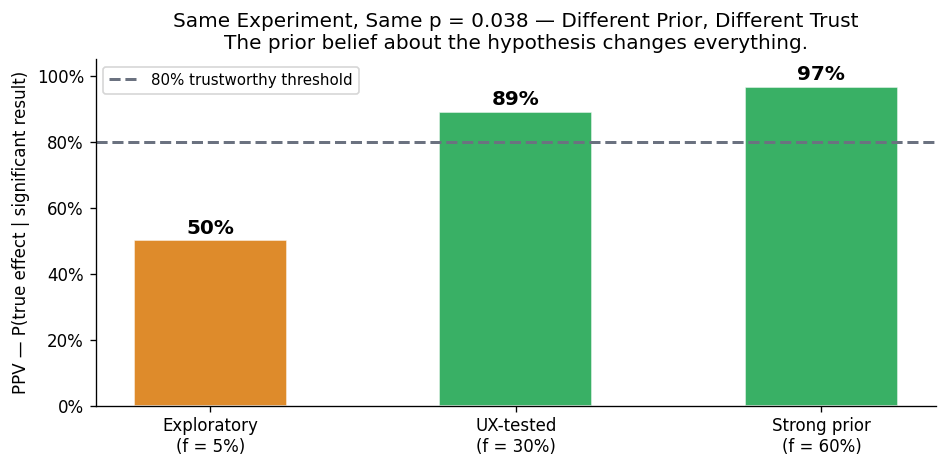

✓ Saved: figures/04_prior_comparison.png


In [15]:
# Side-by-side PPV comparison
fig, ax = plt.subplots(figsize=(8, 4))

scenarios  = ['Exploratory\n(f = 5%)', 'UX-tested\n(f = 30%)',
              'Strong prior\n(f = 60%)']
priors_cmp = [0.05, 0.30, 0.60]
from abaudit._stats import ppv as _ppv_fn
ppvs_cmp   = [_ppv_fn(f, result.power, ALPHA) for f in priors_cmp]
bar_colors = [RED if p < 0.50 else ORANGE if p < 0.80 else GREEN
              for p in ppvs_cmp]

bars = ax.bar(scenarios, ppvs_cmp, color=bar_colors, width=0.5,
              edgecolor='white', alpha=0.85)
ax.axhline(0.80, color=GRAY, ls='--', lw=1.8,
           label='80% trustworthy threshold')

for bar, ppv_val in zip(bars, ppvs_cmp):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{ppv_val:.0%}',
            ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('PPV — P(true effect | significant result)')
ax.set_title(
    'Same Experiment, Same p = 0.038 — Different Prior, Different Trust\n'
    'The prior belief about the hypothesis changes everything.'
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/04_prior_comparison.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/04_prior_comparison.png')

<a id='9'></a>
## 9. Key Takeaways

| Finding | What it means |
|---------|---------------|
| **p = 0.038** | The result is nominally significant |
| **p (corrected) = 0.114** | After Bonferroni correction for 3 metrics, it is NOT significant |
| **PPV = 62%** | Even before correction, only a 62% chance the effect is real |
| **SRM detected** | Traffic split bug — all results are suspect |
| **5 peeks** | Effective α inflated from 5% to 22% |
| **Bias score = 0.50** | Moderate concern — this experiment has real problems |

### The recommendation

**Do not ship based on this result.** Fix the SRM bug, re-run the experiment with:
1. A pre-specified primary metric (conversion only)
2. No interim peeking, or sequential testing if peeking is needed
3. The recommended sample size from `design_summary()` to achieve PPV ≥ 80%

---

### What `abaudit` gives you that standard tools don't

| Standard tool | abaudit |
|--------------|--------|
| Reports p-value | Reports p-value AND PPV |
| Ignores multiple metrics | Applies Bonferroni correction |
| Ignores peeking | Diagnoses optional stopping |
| Ignores traffic split | Runs SRM test |
| Ignores your prior | Uses Ioannidis PPV framework |
| No composite score | Bias score 0–1 |
| No HTML output | Self-contained report |

---

### References

- Ioannidis, J.P.A. (2005). *Why Most Published Research Findings Are False.* PLOS Medicine 2(8): e124.
- Simmons et al. (2011). *False-positive psychology.* Psychological Science 22(11).
- Kohavi et al. (2020). *Trustworthy Online Controlled Experiments.* Cambridge University Press.

---
*Built with [abaudit](https://github.com/aldair-ai/abaudit) · Edwin Aldair Espinoza Zegarra · UCSD MS Data Science 2025–2026*